This series of exercises uses the mdp tool box developped at INRAE

 -  https://pymdptoolbox.readthedocs.io/en/latest/index.html
        
Install it (if not already installed) and import the toolbox and the examples

In [ ]:
%pip install pymdptoolbox

In [3]:
import mdptoolbox, mdptoolbox.example, mdptoolbox.util



## Example: Forest Management

The considered problem is to manage a forest stand with first the objectiveto maintain an old forest for wildlife and second to make money selling cutwood. 

The forest stand is managed by two possible actions: Wait (action 0) or Cut (action 1). An action is decided and applied each time period  at the beginning of the period.

Three states are defined, corresponding to 3 age-class of trees: age-class 0-20years (state 1), 21-40 years (state 2), more than 40 years (state 3).  Thestate 3 correspond to the oldest age-class. 

At the end of a period t, if the state was s at t and action Wait   is choosen, the state at the next time period will be min(s+ 1,3) if no fire occured (the forest grows). But there is a probability p that a fire burns the forest after the application of the action, living the stand at  the youngest age-class (state 1). 

Let p = 0.1 be the probability of wildfire occurence during a time period. The problem is how to manage this stand in a long term vision to maximizethe γ-discounted reward with γ= 0.95


mdptoolbox.example.forest() provides  a modelisation of this problem in the MDP framework. 



#### Q1. create and check  a mdp

In [4]:
# Creating a forest management problem with 3 states, a direct cut reward equal to 1 but for the last state (where it is equal to 2)
# a preservation reward equal to 4, and a probability of fire equal to 0.1
#(for more details,  look  at the "example" module)   
P, R = mdptoolbox.example.forest(6,4,2,0.1)
# the following call checks that the MDP is correctly defined 
#(for more details,  look  at the "util" module : https://pymdptoolbox.readthedocs.io/en/latest/api/util.html)
mdptoolbox.util.check(P, R) # Nothing should happen


 Observe the transition matrix (P)  and the reward matrix (R)   
 
 In particular check  probability to be in state 3 at time t+1 (s’ = 3), when being instate 3 (s = 3) and choosing action Wait (a = 0) at time t, is P(3,3,1) = 1 -p = 0.9 and the associated reward is R(3,1) = 4 

In [5]:
print(f'{P.shape}  :\n {P}')

(2, 6, 6)  :
 [[[0.1 0.9 0.  0.  0.  0. ]
  [0.1 0.  0.9 0.  0.  0. ]
  [0.1 0.  0.  0.9 0.  0. ]
  [0.1 0.  0.  0.  0.9 0. ]
  [0.1 0.  0.  0.  0.  0.9]
  [0.1 0.  0.  0.  0.  0.9]]

 [[1.  0.  0.  0.  0.  0. ]
  [1.  0.  0.  0.  0.  0. ]
  [1.  0.  0.  0.  0.  0. ]
  [1.  0.  0.  0.  0.  0. ]
  [1.  0.  0.  0.  0.  0. ]
  [1.  0.  0.  0.  0.  0. ]]]


In [6]:
print(f'{R.shape}  :\n {R}')

(6, 2)  :
 [[0. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [4. 2.]]


#### Q2 Value Iteration

Apply the policy iteration algorithm and look at  the policy computed

In [7]:
# Apply the policy iteration algorithm
P, R = mdptoolbox.example.forest(3,4,2,0.77)
pi = mdptoolbox.mdp.ValueIterationGS(P, R, 0.9, 0.001, max_iter=10000)
pi.setVerbose()
pi.run()


  Iteration		V-variation
    1		  4.0
    2		  0.7851510000000002
    3		  0.16341323129999985
    4		  0.03460645538108964
    5		  0.014072834002419876
    6		  0.012374242938327895
    7		  0.01088067181567165
Iterating stopped due to maximum number of iterations condition.


In [8]:
# display the policy associated to pi
pi.policy

(0, 1, 0)

In [9]:
# display  its value 

pi.V

(1.0180122122693944, 1.916210991042455, 5.911121633678094)

Which is the minimal for probabilty of fire shall  that implies that it is better to cut   the forest  than wait in state 2 (age 21-40)





**Nous avons trouvé que la valeur minimale de la probabilité de feu = 0.77 afin que l'algorithme détermine la meilleur politique de couper à l'age 2**

#### Q3.  Setting the parameters

Look at https://pymdptoolbox.readthedocs.io/en/latest/api/mdp.html#mdptoolbox.mdp.ValueIteration
    
And apply the Value iteration to the same problem (once with p=0.1, once with p=0.79) 

You can modify the  epsilon threshold and observe the number of iteration needed

In [10]:
P, R = mdptoolbox.example.forest(3,4,2,0.1)
pi = mdptoolbox.mdp.ValueIterationGS(P, R, 0.9, 0.01)
pi.setVerbose()
pi.run()
pi.policy
pi.V

  Iteration		V-variation
    1		  4.0
    2		  2.5029
    3		  0.9122714100000007
    4		  0.0489874447889993
    5		  0.01884470075378175
    6		  0.02190519408847269
    7		  0.0199377846437212
    8		  0.017800582030833567
    9		  0.015864721757266054
    10		  0.014137125367598813
    11		  0.012597471054029086
    12		  0.01122548314916827
    13		  0.01000291691598676
    14		  0.008913500145990128
    15		  0.007942731648860502
    16		  0.0070776894605266705
    17		  0.006306858938952331
    18		  0.005619979500028904
    19		  0.005007908038933806
    20		  0.004462497225517836
    21		  0.003976487054679012
    22		  0.0035434082077507867
    23		  0.003157495939031918
    24		  0.002813613340745036
    25		  0.0025071829652496547
    26		  0.0022341258943576747
    27		  0.001990807444446574
    28		  0.001773988785007674
    29		  0.0015807838262347218
    30		  0.0014086208021169
    31		  0.0012552080374490515
    32		  0.0011185034431555607
    33		  0.0009966873339166

(25.583387976757898, 28.830654635546935, 32.830654635546935)

You can also have a look at the cpu time neeed for the last run of the algorithm ;    
Considering a bigger problem (ex: 100 states), P, R = mdptoolbox.example.forest(100,4,2,0.1)

 - which is the best policy (when to begin the cut ?)
 - which is the average time (on 10 runs)  ?



In [11]:
P, R = mdptoolbox.example.forest(100,4,2,0.1)
pi = mdptoolbox.mdp.ValueIterationGS(P, R, 0.9)
print(f'pi.run() : {pi.run()}\npi.policy {pi.policy}\npi.time : {pi.time}')

P, R = mdptoolbox.example.forest(100,4,2,0.1)
pi = mdptoolbox.mdp.PolicyIteration(P, R, 0.9)
print(f'pi.run() : {pi.run()}\npi.policy {pi.policy}\npi.time : {pi.time}')


pi.run() : None
pi.policy (0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
pi.time : 0.014664888381958008
pi.run() : None
pi.policy (0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
pi.time : 0.006201982498168945


When creating an instance of  ValueIterationGS, you can play with the parameters of the solving class mdptoolbox.mdp.ValueIterationGS(transitions, reward, discount, epsilon=0.01, max_iter=10, initial_value=0, skip_check=False) )

 - (look again at https://pymdptoolbox.readthedocs.io/en/latest/api/mdp.html) .   
 - Which is the best parametrization to have the quickest solving with   epsilon=0.01 ?

In [18]:
import numpy as np
time1 = []
time2 = []

for val in range(10,10010,2500):
    P, R = mdptoolbox.example.forest(val,4,2,0.1)
    pi = mdptoolbox.mdp.ValueIterationGS(P, R, 0.9,epsilon=0.01, max_iter=10000)
    pi.run()
    time1.append(pi.time)
    P, R = mdptoolbox.example.forest(val,4,2,0.1)
    pi = mdptoolbox.mdp.PolicyIteration(P, R, 0.9)
    pi.run()
    time2.append(pi.time)
    print("etat fini")
print(f"etat fini time1.shape {len(time1)} time2.shape {len(time2)}")    


etat fini
etat fini
etat fini
etat fini
etat fini time1.shape 4 time2.shape 4


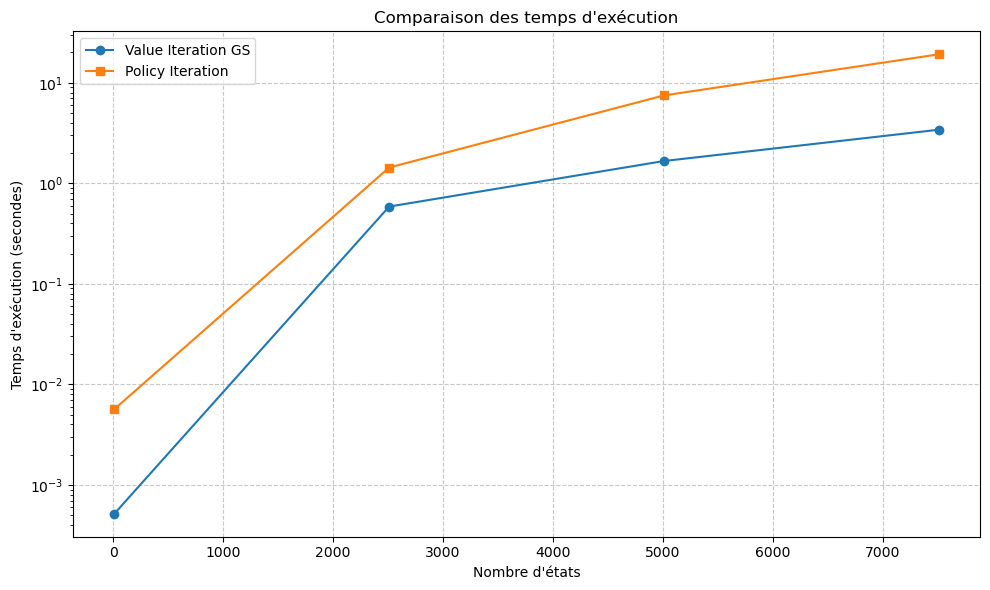

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Supposons que time1 et time2 sont déjà remplis comme dans votre code

# Créer la séquence de valeurs pour l'axe x
x_values = np.arange(10,10010,2500)

# Créer la figure et les axes
fig, ax = plt.subplots(figsize=(10, 6))

# Tracer les deux courbes
ax.plot(x_values, time1, label='Value Iteration GS', marker='o')
ax.plot(x_values, time2, label='Policy Iteration', marker='s')

# Ajouter des étiquettes et un titre
ax.set_xlabel('Nombre d\'états')
ax.set_ylabel('Temps d\'exécution (secondes)')
ax.set_title('Comparaison des temps d\'exécution')

# Ajouter une légende
ax.legend()

# Ajouter une grille
ax.grid(True, linestyle='--', alpha=0.7)

# Ajuster l'échelle de l'axe y si nécessaire
ax.set_yscale('log')  # Utiliser une échelle logarithmique si les différences sont grandes

# Afficher le graphique
plt.tight_layout()
plt.show()

In [30]:
time = np.array(time1)
print(f'{time.shape}')
time[:]

(4,)


array([5.18083572e-04, 5.87283850e-01, 1.66681409e+00, 3.41293383e+00])

In [31]:
a = min(time)
a

0.0005180835723876953

In [35]:
for i in enumerate(time): 
    if a in i : 
        print(i)

(0, 0.0005180835723876953)
